In [15]:
import pandas as pd
import numpy as np

# -----------------------------
# Input assumptions
# -----------------------------

# Three-phase power levels (W)
power_w = np.array([100, 200, 500, 1000, 2000])

V_ll = 240.0              # line-to-line voltage
CT_primary_rating = 100  # 100 A CT
CT_sec_voltage = 0.333   # 0.333 V at rated current

# Extra wiring / crimp resistance to evaluate (ohms)
extra_resistance = [1, 2, 3]

# -----------------------------
# Electrical calculations
# -----------------------------

# Per-phase current for balanced 3-phase system
I_phase = power_w / (np.sqrt(3) * V_ll)

# Ideal CT secondary voltage (mV), linear scaling
baseline_sec_mV = (I_phase / CT_primary_rating) * CT_sec_voltage * 1000

# -----------------------------
# Error model
# -----------------------------
# We model relative error as inversely proportional to signal magnitude.
# This reflects that fixed resistance dominates at low CT signal levels.

# Scale factor chosen so results match earlier order-of-magnitude discussion
K = 2.0  # empirical constant for illustration only

df = pd.DataFrame({
    "Power_W": power_w,
    "I_phase_A": I_phase,
    "CT_sec_mV": baseline_sec_mV
})

for r in extra_resistance:
    df[f"Error_{r}ohm_pct"] = (K * r / I_phase) * 100

df


,Power_W,I_phase_A,CT_sec_mV,Error_1ohm_pct,Error_2ohm_pct,Error_3ohm_pct
0,100,0.240563,0.801073,831.384388,1662.768775,2494.153163
1,200,0.481125,1.602147,415.692194,831.384388,1247.076581
2,500,1.202813,4.005367,166.276878,332.553755,498.830633
3,1000,2.405626,8.010735,83.138439,166.276878,249.415316
4,2000,4.811252,16.021470,41.569219,83.138439,124.707658


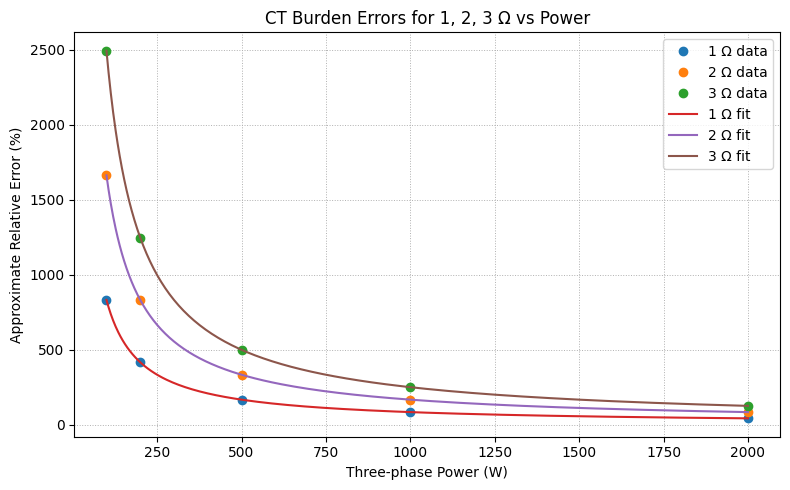

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Power levels (three phase) in watts
power_w = df["Power_W"].values

# Approximate relative error (%) for each extra burden
error_1ohm = df["Error_1ohm_pct"].values
error_2ohm = df["Error_2ohm_pct"].values
error_3ohm = df["Error_3ohm_pct"].values

# Create smooth x values for interpolation (log-spaced)
x_smooth = np.logspace(np.log10(power_w.min()), np.log10(power_w.max()), 200)

# Fit a low-order polynomial in log-log space (effectively a best-fit power law)
coeffs_1 = np.polyfit(np.log10(power_w), np.log10(error_1ohm), 1)
coeffs_2 = np.polyfit(np.log10(power_w), np.log10(error_2ohm), 1)
coeffs_3 = np.polyfit(np.log10(power_w), np.log10(error_3ohm), 1)

# Evaluate polynomial fits
y_fit_1 = 10**np.polyval(coeffs_1, np.log10(x_smooth))
y_fit_2 = 10**np.polyval(coeffs_2, np.log10(x_smooth))
y_fit_3 = 10**np.polyval(coeffs_3, np.log10(x_smooth))

plt.figure(figsize=(8, 5))

# Plot original data points
plt.plot(power_w, error_1ohm, 'o', label="1 Ω data")
plt.plot(power_w, error_2ohm, 'o', label="2 Ω data")
plt.plot(power_w, error_3ohm, 'o', label="3 Ω data")

# Plot smooth best-fit curves
plt.plot(x_smooth, y_fit_1, '-', label="1 Ω fit")
plt.plot(x_smooth, y_fit_2, '-', label="2 Ω fit")
plt.plot(x_smooth, y_fit_3, '-', label="3 Ω fit")

# # Log-scale the x axis so spacing makes sense from 10 → 10000
# plt.xscale("log")

plt.xlabel("Three-phase Power (W)")
plt.ylabel("Approximate Relative Error (%)")
plt.title("CT Burden Errors for 1, 2, 3 Ω vs Power")

plt.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.legend()
plt.tight_layout()

plt.show()
